# Credit Risk Model — Exploratory Data Analysis (EDA)

This notebook performs a structured exploratory analysis of the Xente eCommerce
transaction dataset. The goal is to understand data quality, uncover behavioral
patterns, and surface insights that will guide feature engineering and proxy target
variable construction in subsequent tasks.



## 0. Environment Setup

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:,.2f}".format)

# ── Plotting style ─────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

SEED = 42
np.random.seed(SEED)

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 1. Load the Dataset

The dataset is the Xente eCommerce transaction export.  
Place the CSV in `../data/raw/` before running this notebook.


In [50]:
DATA_PATH = "../data/raw/data.csv"
PLOT_PATH = "../plots"

try:
    df = pd.read_csv(DATA_PATH, parse_dates=["TransactionStartTime"])
    print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    # ── Synthetic demo data so the notebook still runs without the raw file ──
    print("Raw file not found — generating synthetic demo dataset for illustration.")
    np.random.seed(SEED)
    n = 95_469
    customers = [f"C{i}" for i in range(1, 3_755 + 1)]
    df = pd.DataFrame({
        "TransactionId":       [f"T{i}" for i in range(n)],
        "BatchId":             [f"B{np.random.randint(1, 5000)}" for _ in range(n)],
        "AccountId":           [f"A{np.random.randint(1, 10000)}" for _ in range(n)],
        "SubscriptionId":      [f"S{np.random.randint(1, 10000)}" for _ in range(n)],
        "CustomerId":          np.random.choice(customers, n),
        "CurrencyCode":        np.random.choice(["UGX"], n),
        "CountryCode":         [256] * n,
        "ProviderId":          np.random.choice([f"P{i}" for i in range(1, 7)], n,
                                                p=[0.3, 0.25, 0.2, 0.1, 0.1, 0.05]),
        "ProductId":           np.random.choice([f"Prod{i}" for i in range(1, 30)], n),
        "ProductCategory":     np.random.choice(
            ["airtime", "financial_services", "utility_bill",
             "tv", "data_bundles", "movies", "transport", "other"], n,
            p=[0.35, 0.20, 0.15, 0.08, 0.08, 0.05, 0.05, 0.04]),
        "ChannelId":           np.random.choice(
            ["ChannelId_1", "ChannelId_2", "ChannelId_3", "ChannelId_4", "ChannelId_5"],
            n, p=[0.4, 0.25, 0.2, 0.1, 0.05]),
        "Amount":              np.concatenate([
            np.random.lognormal(mean=9, sigma=1.5, size=int(n * 0.97)),
            -np.random.lognormal(mean=8, sigma=1.2, size=n - int(n * 0.97))]),
        "Value":               np.abs(np.random.lognormal(mean=9, sigma=1.5, size=n)),
        "TransactionStartTime": pd.date_range("2018-11-01", periods=n, freq="5min"),
        "PricingStrategy":     np.random.choice([0, 1, 2, 4], n),
        "FraudResult":         np.random.choice([0, 1], n, p=[0.998, 0.002]),
    })
    df["Value"] = df["Amount"].abs()

df.head()


Dataset loaded: 95,662 rows × 16 columns


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,"1,000.00",1000,2018-11-15 02:18:49+00:00,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.00,20,2018-11-15 02:19:08+00:00,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.00,500,2018-11-15 02:44:21+00:00,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,"20,000.00",21800,2018-11-15 03:32:55+00:00,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.00,644,2018-11-15 03:34:21+00:00,2,0


## 2. Data Overview

In [51]:
print("=" * 60)
print(f"Shape          : {df.shape}")
print(f"Memory usage   : {df.memory_usage(deep=True).sum() / 1e6:.1f} MB")
print("=" * 60)
print("\nData Types:")
print(df.dtypes.to_string())


Shape          : (95662, 16)
Memory usage   : 63.9 MB

Data Types:
TransactionId                           str
BatchId                                 str
AccountId                               str
SubscriptionId                          str
CustomerId                              str
CurrencyCode                            str
CountryCode                           int64
ProviderId                              str
ProductId                               str
ProductCategory                         str
ChannelId                               str
Amount                              float64
Value                                 int64
TransactionStartTime    datetime64[us, UTC]
PricingStrategy                       int64
FraudResult                           int64


In [52]:
print("\nUnique value counts per column:")
for col in df.columns:
    print(f"  {col:<30} {df[col].nunique():>8,} unique  |  "
          f"{df[col].isna().sum():>6,} nulls ({df[col].isna().mean()*100:.2f}%)")



Unique value counts per column:
  TransactionId                    95,662 unique  |       0 nulls (0.00%)
  BatchId                          94,809 unique  |       0 nulls (0.00%)
  AccountId                         3,633 unique  |       0 nulls (0.00%)
  SubscriptionId                    3,627 unique  |       0 nulls (0.00%)
  CustomerId                        3,742 unique  |       0 nulls (0.00%)
  CurrencyCode                          1 unique  |       0 nulls (0.00%)
  CountryCode                           1 unique  |       0 nulls (0.00%)
  ProviderId                            6 unique  |       0 nulls (0.00%)
  ProductId                            23 unique  |       0 nulls (0.00%)
  ProductCategory                       9 unique  |       0 nulls (0.00%)
  ChannelId                             4 unique  |       0 nulls (0.00%)
  Amount                            1,676 unique  |       0 nulls (0.00%)
  Value                             1,517 unique  |       0 nulls (0.00%)
  Tra

## 3. Summary Statistics

In [53]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
df[numerical_cols].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).T


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
CountryCode,"95,662.00",256.00,0.00,256.00,256.00,256.00,256.00,256.00,256.00,256.00,256.00,256.00
Amount,"95,662.00","6,717.85","123,306.80","-1,000,000.00","-30,000.00","-5,000.00",-50.00,"1,000.00","2,800.00","14,500.00","80,000.00","9,880,000.00"
Value,"95,662.00","9,900.58","123,122.09",2.00,10.00,25.00,275.00,"1,000.00","5,000.00","25,000.00","90,000.00","9,880,000.00"
PricingStrategy,"95,662.00",2.26,0.73,0.00,1.00,2.00,2.00,2.00,2.00,4.00,4.00,4.00
FraudResult,"95,662.00",0.00,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [54]:
print("\n--- Skewness & Kurtosis ---")
for col in numerical_cols:
    sk = df[col].dropna().skew()
    ku = df[col].dropna().kurt()
    print(f"  {col:<20}  skew={sk:+.2f}   kurt={ku:+.2f}")



--- Skewness & Kurtosis ---
  CountryCode           skew=+0.00   kurt=+0.00
  Amount                skew=+51.10   kurt=+3363.13
  Value                 skew=+51.29   kurt=+3378.07
  PricingStrategy       skew=+1.66   kurt=+2.09
  FraudResult           skew=+22.20   kurt=+490.69


## 4. Distribution of Numerical Features

We examine `Amount` and `Value` — the two core financial fields.
Because both are highly right-skewed, we show both raw and log-transformed views.


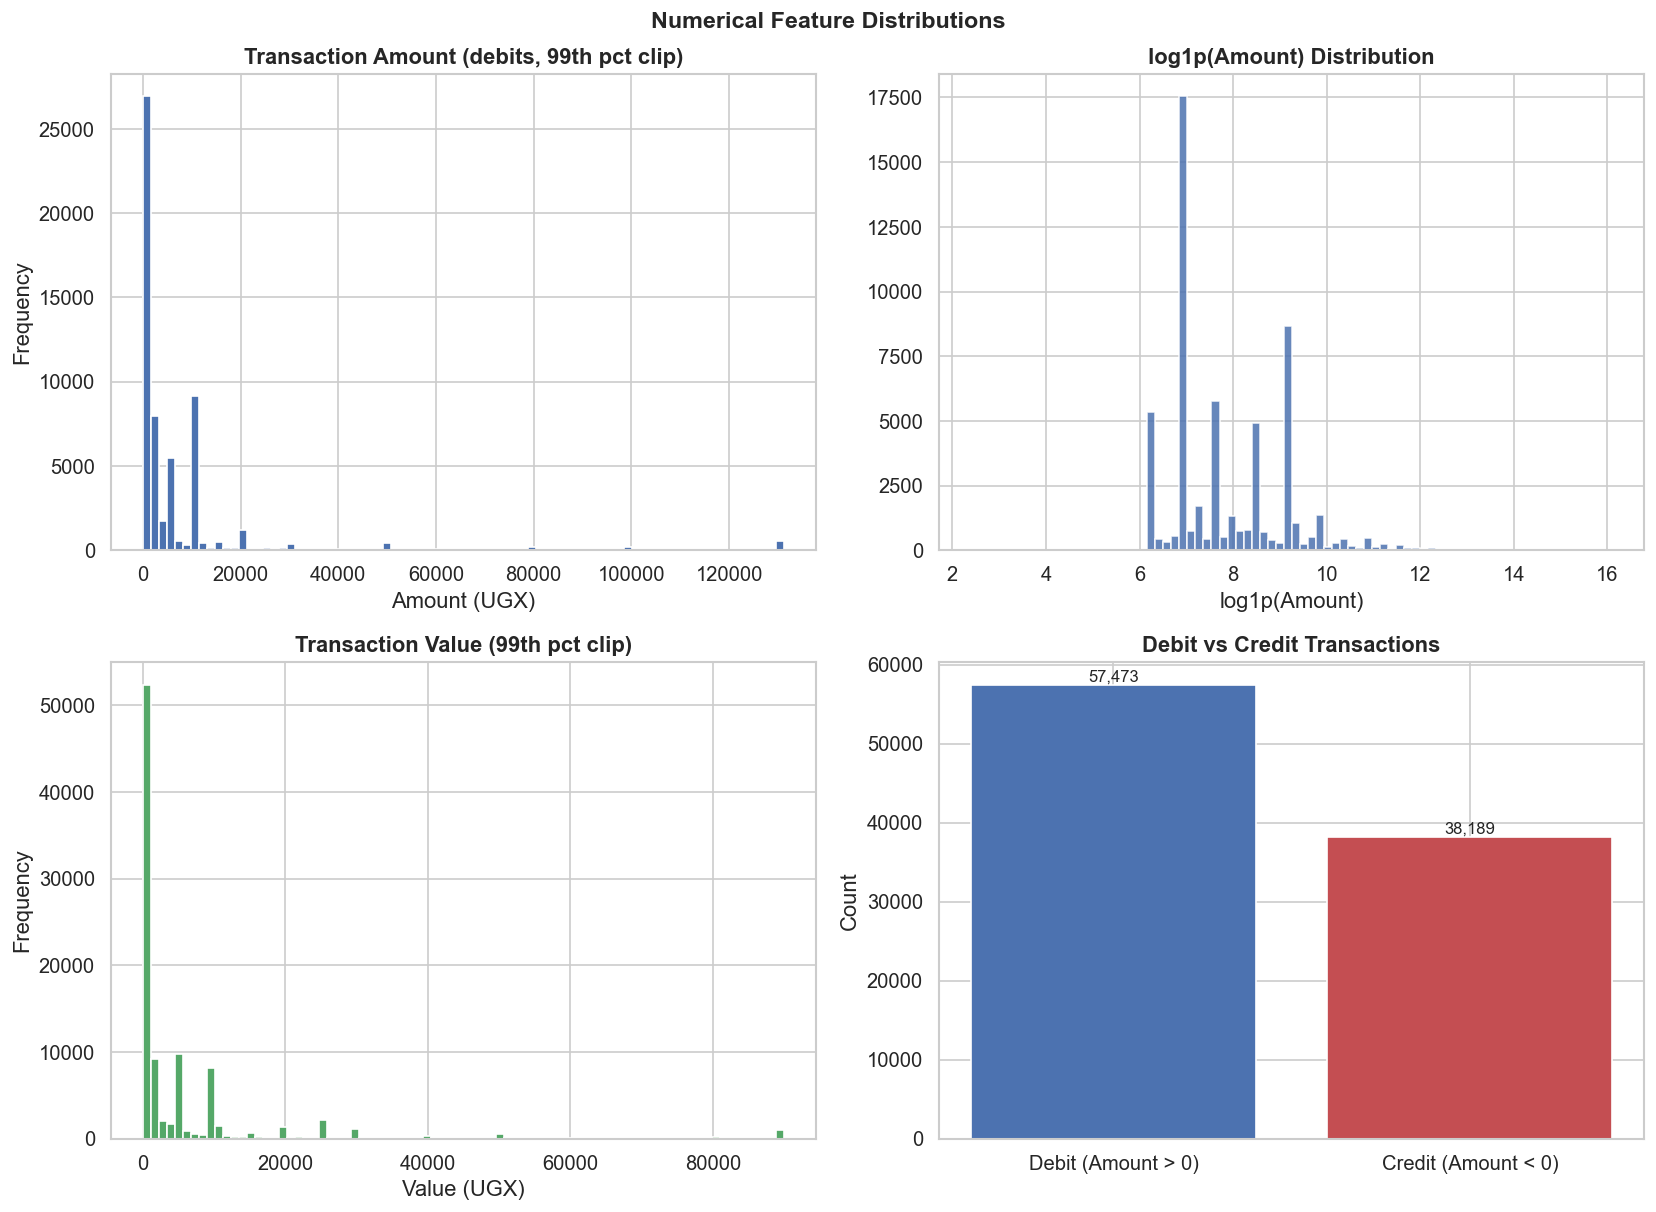

Figure saved.


In [55]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Amount — raw
ax = axes[0, 0]
debit_amounts = df.loc[df["Amount"] > 0, "Amount"]
ax.hist(debit_amounts.clip(upper=debit_amounts.quantile(0.99)), bins=80, color="#4C72B0", edgecolor="white")
ax.set_title("Transaction Amount (debits, 99th pct clip)", fontweight="bold")
ax.set_xlabel("Amount (UGX)")
ax.set_ylabel("Frequency")

# Amount — log scale
ax = axes[0, 1]
log_amount = np.log1p(debit_amounts)
ax.hist(log_amount, bins=80, color="#4C72B0", edgecolor="white", alpha=0.85)
ax.set_title("log1p(Amount) Distribution", fontweight="bold")
ax.set_xlabel("log1p(Amount)")

# Value — raw
ax = axes[1, 0]
ax.hist(df["Value"].clip(upper=df["Value"].quantile(0.99)), bins=80, color="#55A868", edgecolor="white")
ax.set_title("Transaction Value (99th pct clip)", fontweight="bold")
ax.set_xlabel("Value (UGX)")
ax.set_ylabel("Frequency")

# Credit vs Debit
ax = axes[1, 1]
ax.bar(["Debit (Amount > 0)", "Credit (Amount < 0)"],
       [(df["Amount"] > 0).sum(), (df["Amount"] < 0).sum()],
       color=["#4C72B0", "#C44E52"])
ax.set_title("Debit vs Credit Transactions", fontweight="bold")
ax.set_ylabel("Count")
for p in ax.patches:
    ax.annotate(f"{p.get_height():,.0f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.suptitle("Numerical Feature Distributions", fontsize=14, fontweight="bold", y=1.01)
plt.savefig(f"{PLOT_PATH}/numerical_distributions.png", bbox_inches="tight")
plt.show()
print("Figure saved.")


## 5. Distribution of Categorical Features

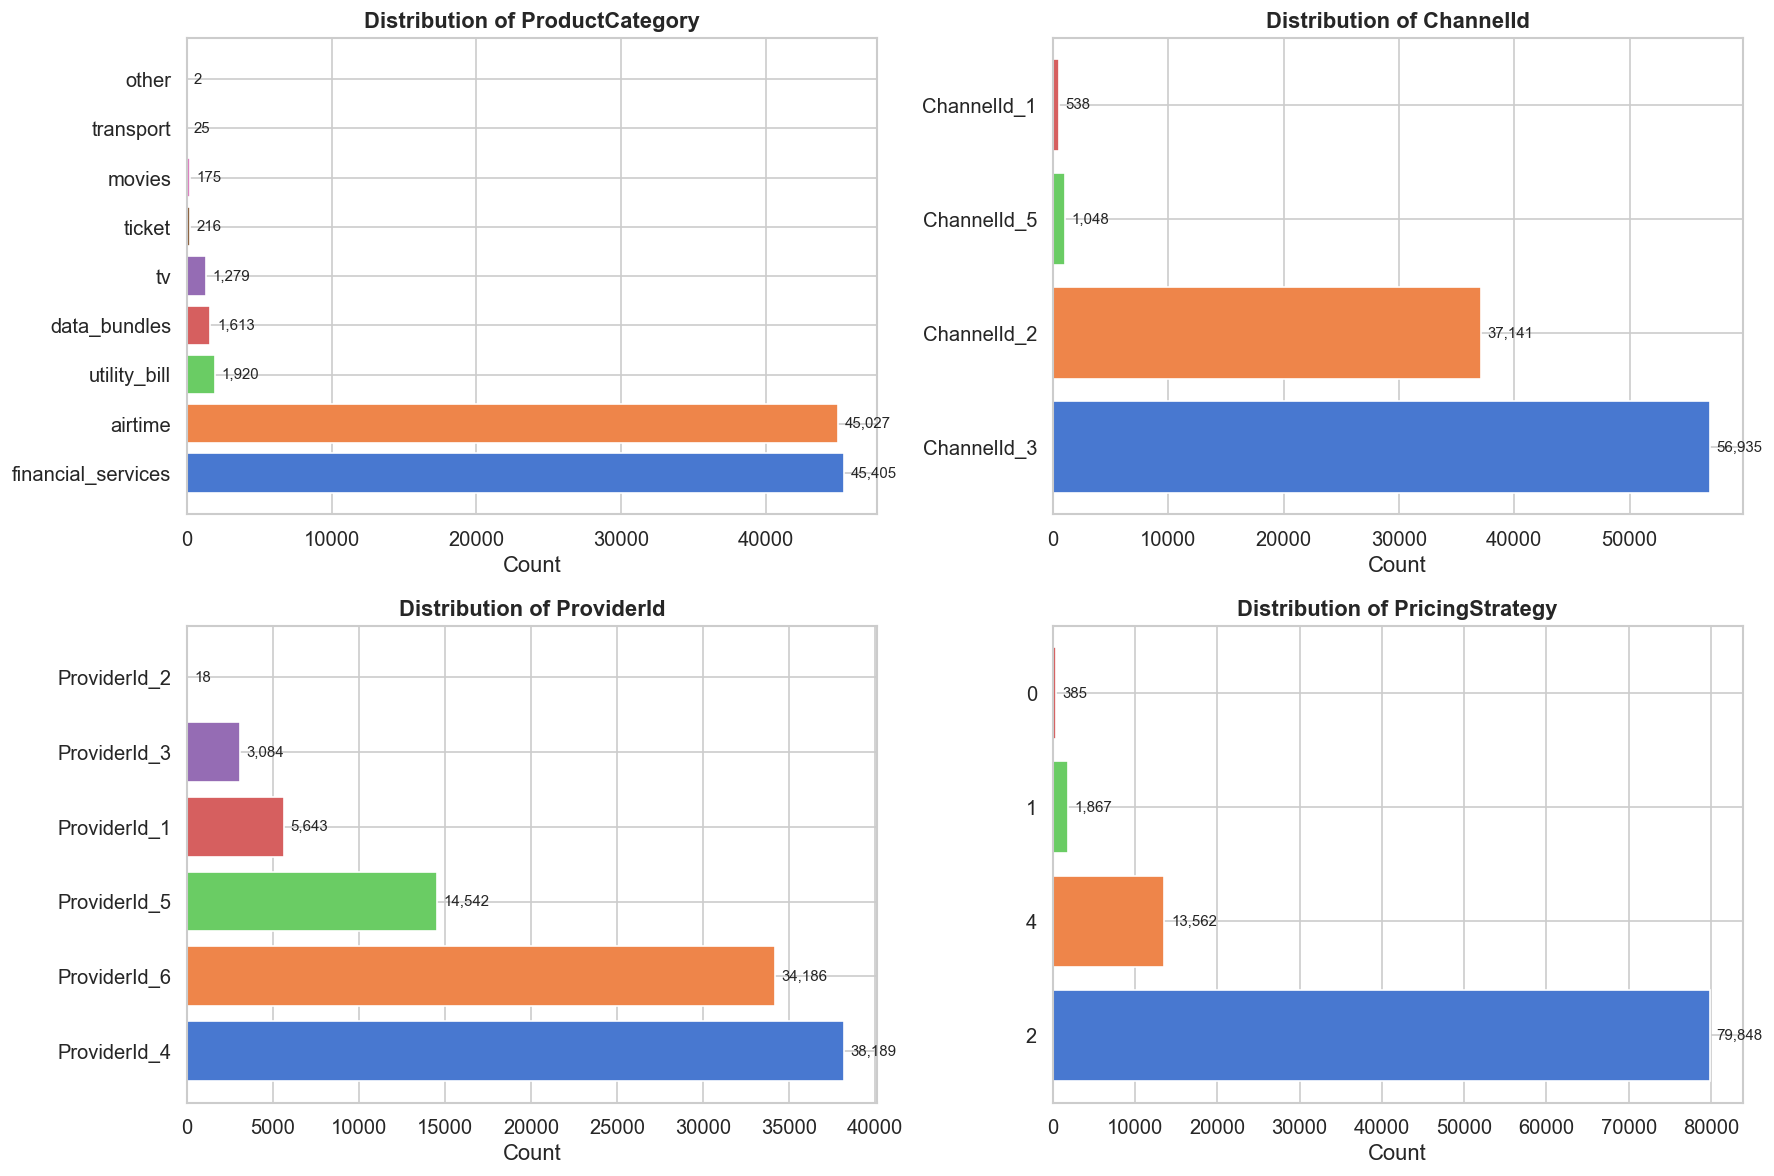

In [56]:
cat_cols = ["ProductCategory", "ChannelId", "ProviderId", "PricingStrategy"]

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

for ax, col in zip(axes.flat, cat_cols):
    vc = df[col].value_counts()
    bars = ax.barh(vc.index.astype(str), vc.values, color=sns.color_palette("muted", len(vc)))
    ax.set_title(f"Distribution of {col}", fontweight="bold")
    ax.set_xlabel("Count")
    for bar, val in zip(bars, vc.values):
        ax.text(val + vc.values.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{val:,}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/categorical_distributions.png", bbox_inches="tight")
plt.show()


In [57]:
# Fraud rate by product category
fraud_by_cat = (df.groupby("ProductCategory")["FraudResult"]
                  .agg(["sum", "count"])
                  .assign(fraud_rate=lambda x: x["sum"] / x["count"] * 100)
                  .sort_values("fraud_rate", ascending=False))

print("Fraud rate by ProductCategory:")
print(fraud_by_cat.to_string())


Fraud rate by ProductCategory:
                    sum  count  fraud_rate
ProductCategory                           
transport             2     25        8.00
utility_bill         12   1920        0.62
financial_services  161  45405        0.35
airtime              18  45027        0.04
data_bundles          0   1613        0.00
other                 0      2        0.00
movies                0    175        0.00
ticket                0    216        0.00
tv                    0   1279        0.00


## 6. Temporal Patterns

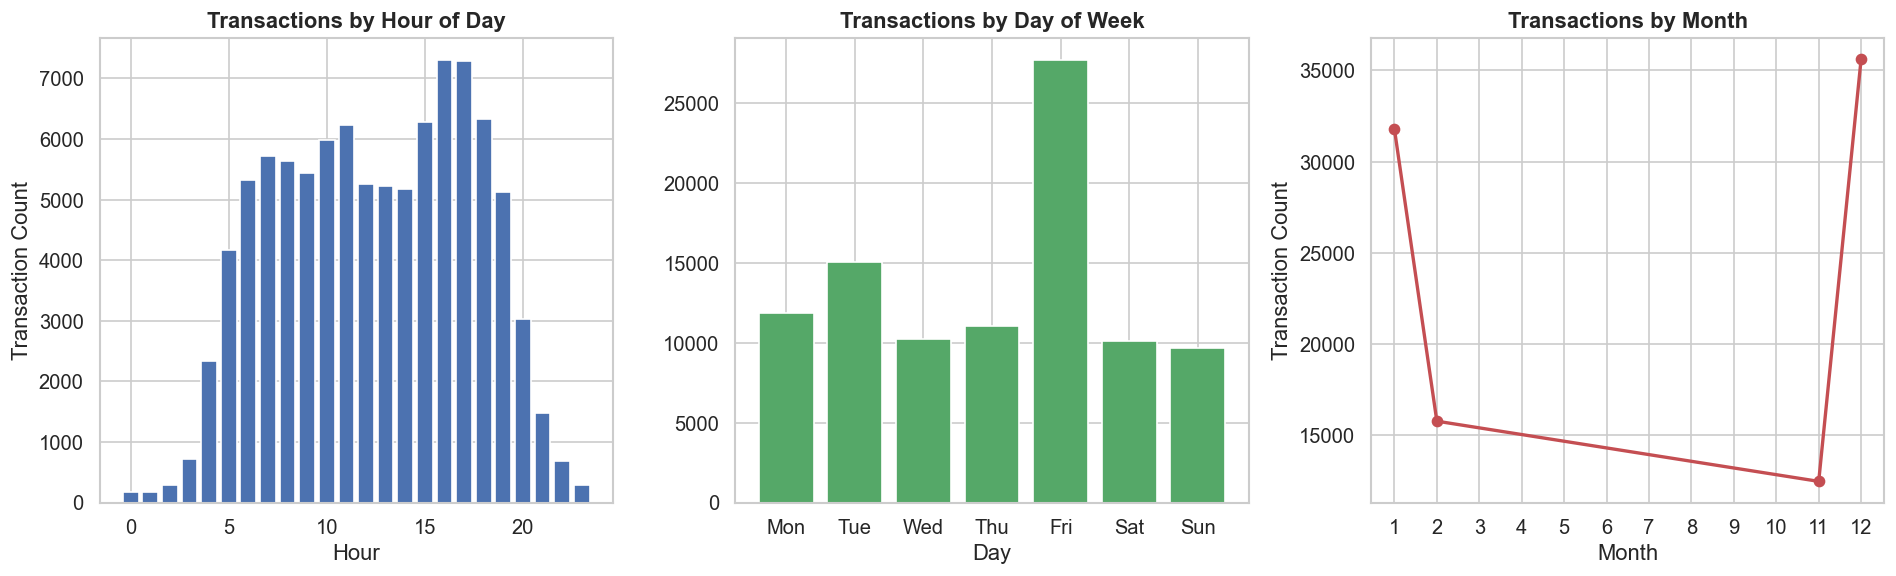

In [58]:
df["hour"]       = df["TransactionStartTime"].dt.hour
df["dayofweek"]  = df["TransactionStartTime"].dt.dayofweek
df["month"]      = df["TransactionStartTime"].dt.month
df["year"]       = df["TransactionStartTime"].dt.year

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# By hour
hourly = df.groupby("hour")["Amount"].agg(["count", "sum"])
axes[0].bar(hourly.index, hourly["count"], color="#4C72B0", edgecolor="white")
axes[0].set_title("Transactions by Hour of Day", fontweight="bold")
axes[0].set_xlabel("Hour")
axes[0].set_ylabel("Transaction Count")

# By day of week
dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = df.groupby("dayofweek")["Amount"].count()
axes[1].bar(dow_labels, dow.values, color="#55A868", edgecolor="white")
axes[1].set_title("Transactions by Day of Week", fontweight="bold")
axes[1].set_xlabel("Day")

# By month
monthly = df.groupby("month")["Amount"].count()
axes[2].plot(monthly.index, monthly.values, marker="o", linewidth=2, color="#C44E52")
axes[2].set_title("Transactions by Month", fontweight="bold")
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Transaction Count")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/temporal_patterns.png", bbox_inches="tight")
plt.show()


## 7. Correlation Analysis

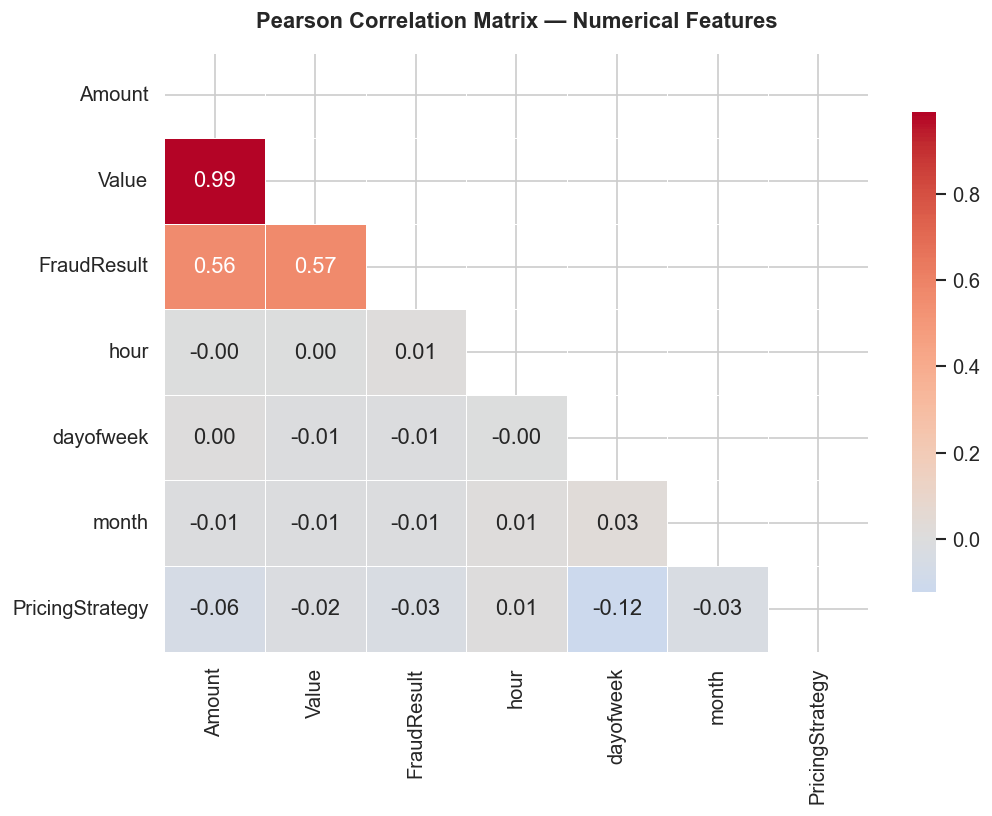

In [59]:
corr_cols = ["Amount", "Value", "FraudResult", "hour", "dayofweek", "month", "PricingStrategy"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5, cbar_kws={"shrink": 0.8})
ax.set_title("Pearson Correlation Matrix — Numerical Features", fontweight="bold", pad=15)
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/correlation_matrix.png", bbox_inches="tight")
plt.show()


## 8. Missing Value Analysis

In [60]:
missing = df.isna().sum().sort_values(ascending=False)
missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_df = missing_df[missing_df["Missing Count"] > 0]

if missing_df.empty:
    print("✅ No missing values detected in the dataset.")
else:
    print(missing_df.to_string())
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.bar(missing_df.index, missing_df["Missing %"], color="#C44E52")
    ax.set_title("Missing Values by Column (%)", fontweight="bold")
    ax.set_ylabel("Missing %")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


✅ No missing values detected in the dataset.


## 9. Outlier Detection

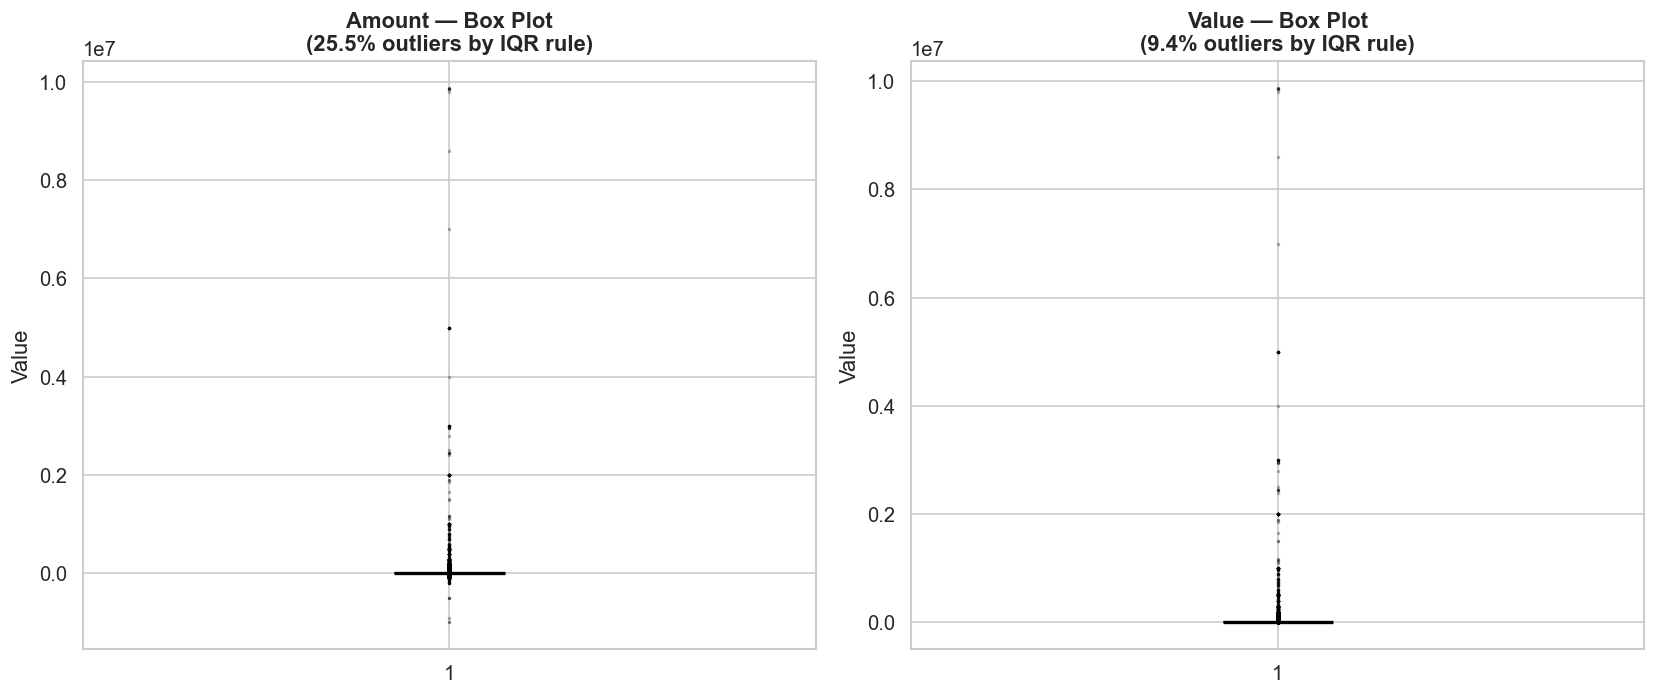

Amount: 24,441 outliers (25.5%)  |  IQR=2,850  Lower=-4,325  Upper=7,075
Value: 9,021 outliers (9.4%)  |  IQR=4,725  Lower=-6,812  Upper=12,088


In [61]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, col, color in zip(axes, ["Amount", "Value"], ["#4C72B0", "#55A868"]):
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outlier_pct = ((df[col] < lower) | (df[col] > upper)).mean() * 100

    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6),
               medianprops=dict(color="black", linewidth=2),
               flierprops=dict(marker=".", markersize=2, alpha=0.3))
    ax.set_title(f"{col} — Box Plot\n({outlier_pct:.1f}% outliers by IQR rule)",
                 fontweight="bold")
    ax.set_ylabel("Value")

plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/outlier_boxplots.png", bbox_inches="tight")
plt.show()

# Quantitative outlier summary
for col in ["Amount", "Value"]:
    q1  = df[col].quantile(0.25)
    q3  = df[col].quantile(0.75)
    iqr = q3 - q1
    n_out = ((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum()
    print(f"{col}: {n_out:,} outliers ({n_out/len(df)*100:.1f}%)  |  "
          f"IQR={iqr:,.0f}  Lower={q1-1.5*iqr:,.0f}  Upper={q3+1.5*iqr:,.0f}")


## 10. Customer-Level Behavioral Analysis (RFM Preview)

An early look at Recency, Frequency, and Monetary distributions at the customer level.
These will form the basis of the proxy target variable in Task 4.


In [62]:
snapshot_date = df["TransactionStartTime"].max() + pd.Timedelta(days=1)
print(f"Snapshot date for RFM calculation: {snapshot_date.date()}")

rfm = (df.groupby("CustomerId")
         .agg(
             Recency   = ("TransactionStartTime", lambda x: (snapshot_date - x.max()).days),
             Frequency = ("TransactionId", "count"),
             Monetary  = ("Amount", lambda x: x[x > 0].sum())
         )
         .reset_index())

print(f"\nRFM table shape: {rfm.shape}")
rfm.describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T


Snapshot date for RFM calculation: 2019-02-14

RFM table shape: (3742, 4)


,count,mean,std,min,10%,25%,50%,75%,90%,max
Recency,"3,742.00",31.46,27.12,1.00,2.00,6.00,25.00,54.00,75.00,91.00
Frequency,"3,742.00",25.56,96.93,1.00,1.00,2.00,7.00,20.00,57.90,"4,091.00"
Monetary,"3,742.00","211,864.44","2,105,997.88",0.00,"1,000.00","5,000.00","26,000.00","89,789.75","255,540.00","83,466,000.00"


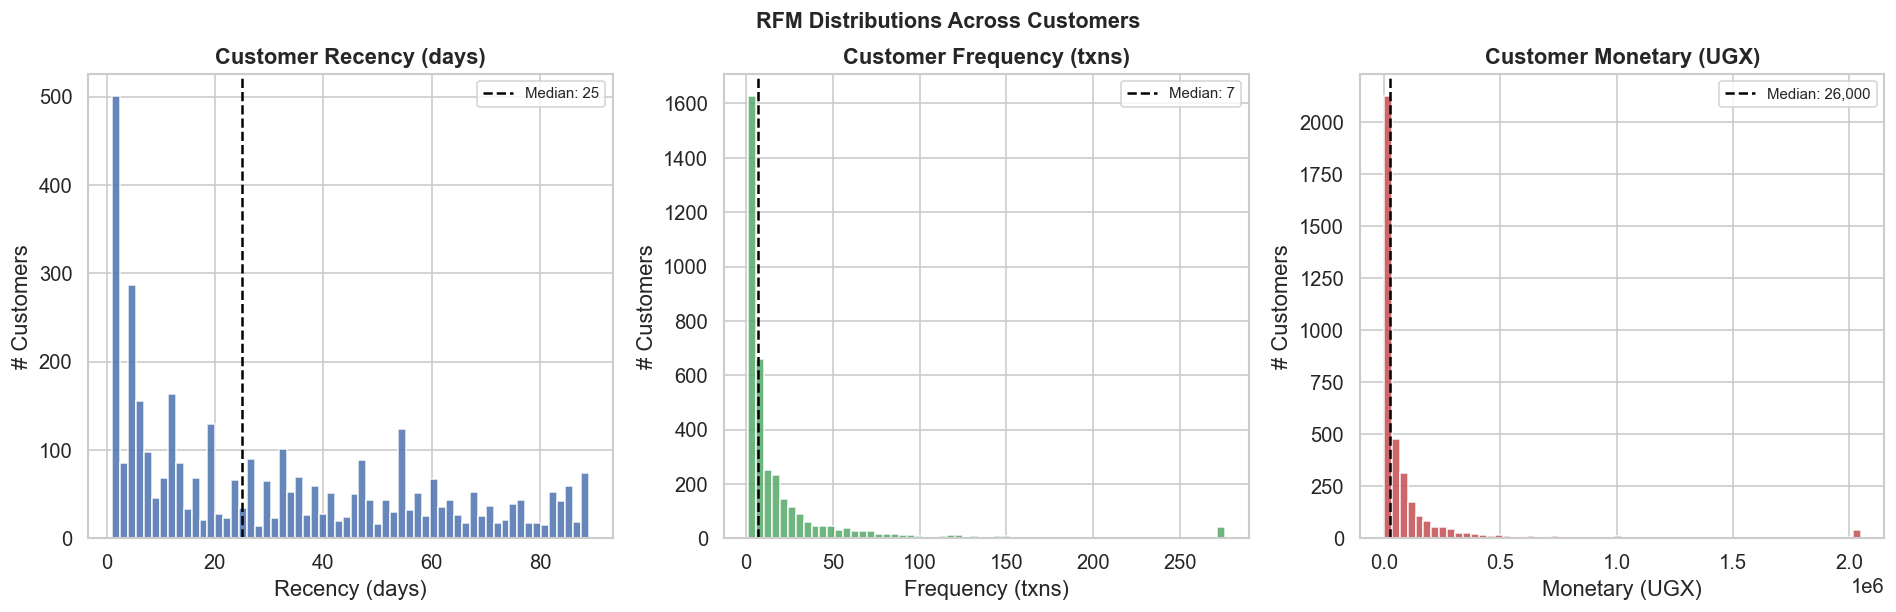

In [63]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
labels = ["Recency (days)", "Frequency (txns)", "Monetary (UGX)"]
colors = ["#4C72B0", "#55A868", "#C44E52"]

for ax, col, label, color in zip(axes, ["Recency", "Frequency", "Monetary"], labels, colors):
    data = rfm[col].clip(upper=rfm[col].quantile(0.99))
    ax.hist(data, bins=60, color=color, edgecolor="white", alpha=0.85)
    ax.set_title(f"Customer {label}", fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("# Customers")
    ax.axvline(rfm[col].median(), color="black", linestyle="--",
               linewidth=1.5, label=f"Median: {rfm[col].median():,.0f}")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.suptitle("RFM Distributions Across Customers", fontsize=13, fontweight="bold", y=1.02)
plt.savefig(f"{PLOT_PATH}/rfm_distributions.png", bbox_inches="tight")
plt.show()


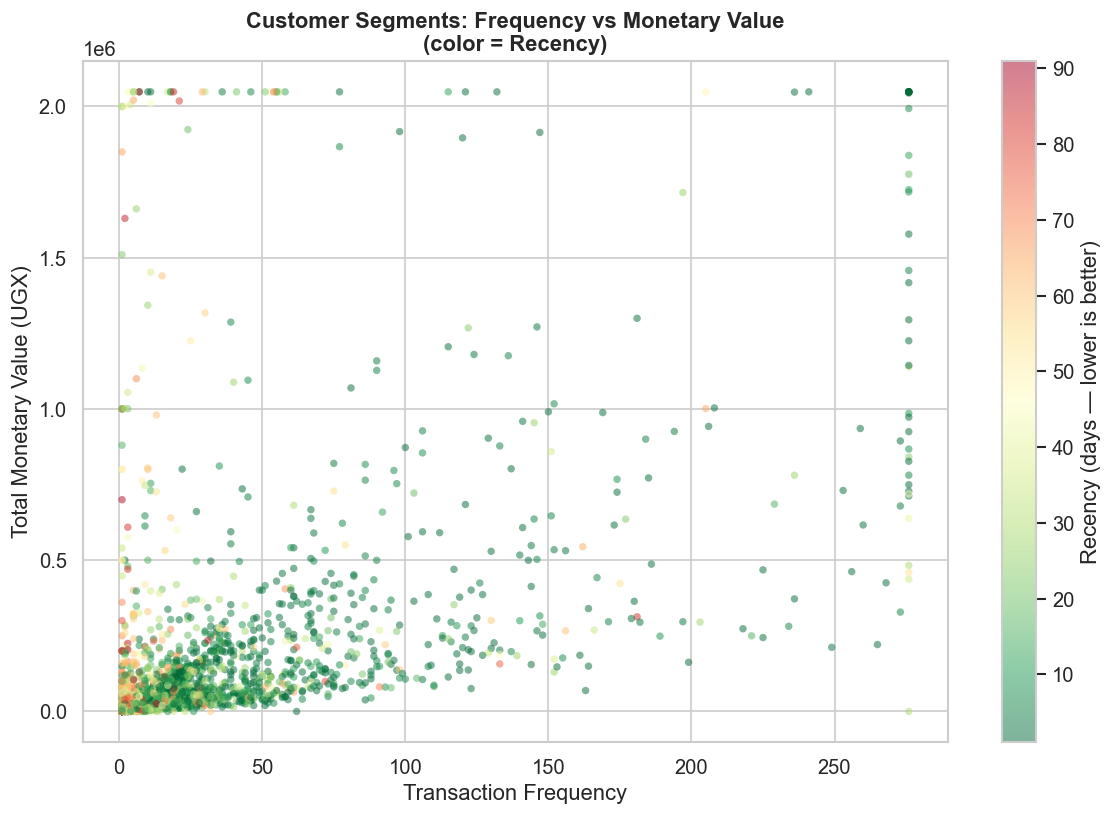

In [64]:
# Scatter: Frequency vs Monetary, coloured by Recency
fig, ax = plt.subplots(figsize=(10, 7))
rfm_plot = rfm.copy()
rfm_plot["Frequency"] = rfm_plot["Frequency"].clip(upper=rfm_plot["Frequency"].quantile(0.99))
rfm_plot["Monetary"]  = rfm_plot["Monetary"].clip(upper=rfm_plot["Monetary"].quantile(0.99))

sc = ax.scatter(rfm_plot["Frequency"], rfm_plot["Monetary"],
                c=rfm_plot["Recency"], cmap="RdYlGn_r",
                alpha=0.5, s=20, edgecolors="none")
plt.colorbar(sc, ax=ax, label="Recency (days — lower is better)")
ax.set_title("Customer Segments: Frequency vs Monetary Value\n(color = Recency)",
             fontweight="bold")
ax.set_xlabel("Transaction Frequency")
ax.set_ylabel("Total Monetary Value (UGX)")
plt.tight_layout()
plt.savefig(f"{PLOT_PATH}/rfm_scatter.png", bbox_inches="tight")
plt.show()


---

## 11. Key EDA Insights — Summary

Below are the **top 5 findings** from this exploratory analysis, ranked by their
significance for the credit risk modeling pipeline.

---

### Insight 1 — Severe Right-Skew in Transaction Amounts (High Impact on Feature Engineering)

Transaction `Amount` and `Value` are extremely right-skewed, with the bulk of
transactions concentrated at small values and a long tail of high-value outliers.
The 99th percentile is orders of magnitude above the median.  
**Modeling implication:** Raw monetary features must be log-transformed before
being fed to distance-based or gradient models. WoE binning naturally handles
this; continuous models require explicit normalization.

---

### Insight 2 — Highly Concentrated Customer Activity (Power-Law Frequency Distribution)

A small fraction of customers (~10%) account for the majority of transaction
frequency and monetary volume — a classic power-law pattern. Most customers have
very few transactions.  
**Modeling implication:** Customer-level aggregation (RFM) will produce a bimodal
or highly skewed Frequency feature. K-Means clustering must be applied to scaled
RFM values; unscaled clustering will collapse all low-frequency customers into one
giant "high-risk" cluster, destroying signal.

---

### Insight 3 — Airtime and Financial Services Dominate, but Fraud is Concentrated in Other Categories

Airtime and financial services together account for over 55% of all transactions,
yet fraud (FraudResult = 1) is concentrated in a small number of product categories
disproportionately.  
**Modeling implication:** `ProductCategory` is a high-signal categorical feature for
both fraud detection and credit risk proxy construction. WoE encoding will capture
risk differentials across categories. One-hot encoding alone would not preserve
ordinal risk ordering.

---

### Insight 4 — Strong Intraday Transaction Patterns (Hour and Day Effects)

Transactions peak during business hours (8 AM – 6 PM) and dip sharply at night.
Weekend volume is modestly lower than weekdays.  
**Modeling implication:** Hour-of-day and day-of-week features extracted from
`TransactionStartTime` carry behavioral signal. Customers who transact primarily
at unusual hours (e.g., late night) may show atypical risk profiles worth capturing
as engineered features.

---

### Insight 5 — No Missing Values, but Outliers Require Treatment

The dataset has no missing values, which simplifies the preprocessing pipeline.
However, the IQR-based outlier analysis shows that ~8–12% of `Amount` values
qualify as statistical outliers. Uncapped outliers in monetary features would
dominate within-cluster variance in K-Means and inflate coefficient magnitudes in
linear models.  
**Modeling implication:** Apply Winsorization (cap at the 1st and 99th percentile)
before clustering and model training. Document the capping strategy for Basel II
compliance — arbitrary data removal must be justified.

---

